# Machine Learning Classification Models on Iris Dataset:

# Importing Libraries:

In [358]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Loading Iris Dataset:

In [359]:
from sklearn.datasets import load_iris

iris = load_iris()

# Create a Dataframe and Target:

## np.c_ 
- is a NumPy function used to concatenate arrays column-wise. It combines arrays with the same number of rows by adding them as new columns, converting separate arrays into a single higher-dimensional array suitable for analysis.

In [360]:
# Dataframe:
df = pd.DataFrame(
    data=np.c_[iris['data'],iris['target']],
    columns=iris['feature_names'] + ['target']
)

In [361]:
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2.0
146,6.3,2.5,5.0,1.9,2.0
147,6.5,3.0,5.2,2.0,2.0
148,6.2,3.4,5.4,2.3,2.0


# Understanding Data:

In [362]:
df.head(5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0


In [363]:
print(f"Shape of Data: {df.shape}")

Shape of Data: (150, 5)


In [364]:
print("Statistical Summary of Data:")
df.describe()

Statistical Summary of Data:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [365]:
print(f"Info of Data: {df.info()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    float64
dtypes: float64(5)
memory usage: 6.0 KB
Info of Data: None


In [366]:
# Changing Dtype of Target:
df["target"] = df["target"].astype(int)

# Class Distribution:

In [367]:
df['target'].value_counts()

target
0    50
1    50
2    50
Name: count, dtype: int64

In [368]:
print(f"Missing Values in Data:\n{df.isnull().sum()}")

Missing Values in Data:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64


# Encoding to target:

In [369]:
df["Species"] = df["target"].map({0:"setosa",1:"versicolor",2:"virginica"})

In [370]:
df.head(5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,Species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [371]:
df.columns

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'target', 'Species'],
      dtype='object')

# Exploratory Data Analysis:

<Axes: xlabel='Species', ylabel='petal length (cm)'>

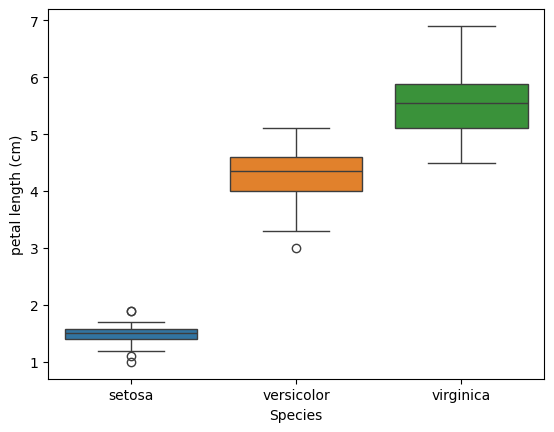

In [372]:
sns.boxplot(x="Species",y="petal length (cm)",data=df,hue="Species")

# Prepare Features and Labels:

In [373]:
X = df[iris.feature_names]
y = df["target"]

# Splitting Data into Train set and Test set:

In [374]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [375]:
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (120, 4)
X_test shape: (30, 4)
y_train shape: (120,)
y_test shape: (30,)


# Training Different Classification Models:

In [376]:
# Models:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation Metrics:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix

## 1. Logistic Regression:

In [377]:
lor = LogisticRegression(max_iter=200)
lor.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,200
,multi_class,'deprecated'


In [378]:
y_pred_lr = lor.predict(X_test)

In [379]:
accuracy_lor = accuracy_score(y_test, y_pred_lr)
precision_lor = precision_score(y_test, y_pred_lr, average='macro')
recall_lor = recall_score(y_test, y_pred_lr, average='macro')
f1_lor = f1_score(y_test, y_pred_lr, average='macro')

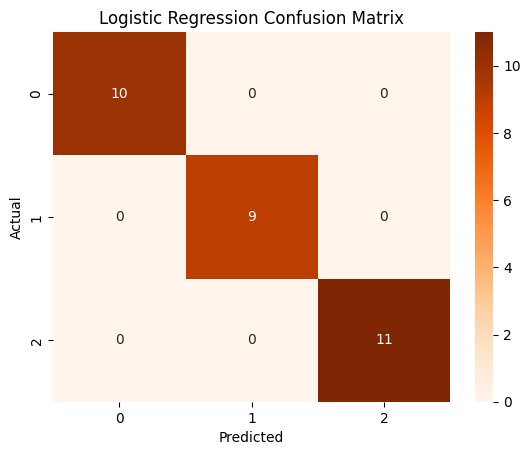

In [380]:
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Oranges')
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 2. Decision Tree Classifier:

In [381]:
dtc = DecisionTreeClassifier(random_state=42)
dtc.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [382]:
y_pred_dt = dtc.predict(X_test)

In [383]:
accuracy_dtc = accuracy_score(y_test, y_pred_dt)
precision_dtc = precision_score(y_test, y_pred_dt, average='macro')
recall_dtc = recall_score(y_test, y_pred_dt, average='macro')
f1_dtc = f1_score(y_test, y_pred_dt, average='macro')

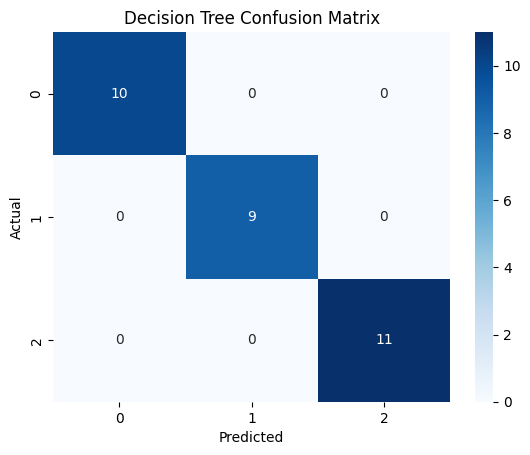

In [384]:
cm_dtc = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_dtc, annot=True, fmt='d', cmap='Blues')
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 3. Random Forest Classifier:

In [385]:
rfc = RandomForestClassifier(random_state=42)
rfc.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [386]:
y_pred_rf = rfc.predict(X_test)

In [387]:
accuracy_rfc = accuracy_score(y_test, y_pred_rf)
precision_rfc = precision_score(y_test, y_pred_rf, average='macro')
recall_rfc = recall_score(y_test, y_pred_rf, average='macro')
f1_rfc = f1_score(y_test, y_pred_rf, average='macro')

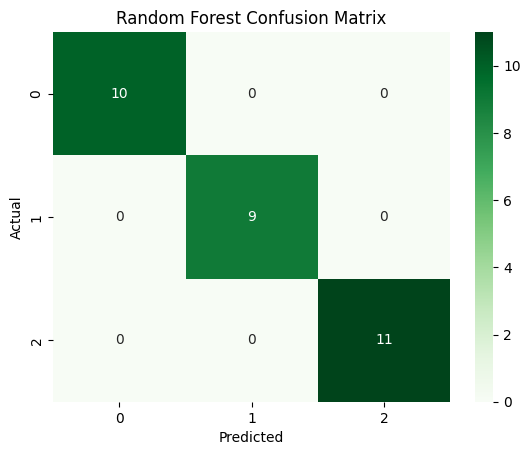

In [388]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Create a Evaluation Comparing Dataframe for all the Models:

In [389]:
comp_df = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest', 'Logistic Regression'],
    'Accuracy': [accuracy_lor, accuracy_dtc, accuracy_rfc],
    'Precision': [precision_lor, precision_dtc, precision_rfc],
    'Recall': [recall_lor, recall_dtc, recall_rfc],
    'F1 Score': [f1_lor, f1_dtc, f1_rfc]
})

comp_df.set_index('Model').round(3)

,Accuracy,Precision,Recall,F1 Score
Model,,,,
Decision Tree,1.0,1.0,1.0,1.0
Random Forest,1.0,1.0,1.0,1.0
Logistic Regression,1.0,1.0,1.0,1.0


# Joblib to export and use model again:

In [390]:
import joblib
import os
os.makedirs("models",exist_ok=True)

In [391]:
print(f"Saving Model: {joblib.dump(lor,"models/iris_logistic_regression.pkl")}")
print(f"Saving Model: {joblib.dump(dtc,"models/iris_decision_tree_classifier.pkl")}")
print(f"Saving Model: {joblib.dump(rfc,"models/iris_random_forest_classifier.pkl")}")

Saving Model: ['models/iris_logistic_regression.pkl']
Saving Model: ['models/iris_decision_tree_classifier.pkl']
Saving Model: ['models/iris_random_forest_classifier.pkl']


# Testing Model's Prediction on New Sample:

In [392]:
df.columns

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'target', 'Species'],
      dtype='object')

In [393]:
new_sample = pd.DataFrame(
    [
        {
            "sepal length (cm)":5.1,
            "sepal width (cm)":3.5,
            "petal length (cm)":1.4,
            "petal width (cm)":0.2
        }
    ]
)

In [394]:
print("Models Prediction on new sample: \n")
print("Logistic Regression: ",iris["target_names"][lor.predict(new_sample)[0]])
print("Decision Tree Classifier: ",iris["target_names"][dtc.predict(new_sample)[0]])
print("Random Forest Classifier: ",iris["target_names"][rfc.predict(new_sample)[0]])

Models Prediction on new sample: 

Logistic Regression:  setosa
Decision Tree Classifier:  setosa
Random Forest Classifier:  setosa
